# K-mirror image rotator inserted between scan lens and tube lens (scanning-space configuration)

*Copyright (c) 2026 Nikita Vladimirov, Peter Rupprecht and Claude Opus 5
(`claude-opus-5`). Licensed under the GNU General Public License v3.0 (GPL-3.0).*

This simulation describes the geometric optics properties of a K-mirror (for scan field rotation) inserted in the beam path of a two-photon raster scanning microscope, after the scan lens and before the tube lens. This notebook computes the **clipping of the beam** when scanning angles are non-zero.

The notebook uses a sequential model of a two-photon excitation path from the scan block to the exit of the
K-mirror housing with paraxial lenses only.

**Chain.** Laser (1.2 mm $1/e^2$, laser specifications) $\to$ 4f expander $f_1..f_4 = 25/60/150/75$ mm $\to$ 2D scan
block (galvo + resonant, $\pm 13^\circ$ optical each) $\to$ scan lens $f = 100$ mm $\to$
*ScienceEdge IRMU-FD30* K-mirror housing, its exit wall 10 mm
before the tube lens $\to$ tube lens
$f = 375$ mm, placed at an on-axis *path* of $f_{scan} + f_{tube}$ from the scan lens, so
the output is collimated and the scan pivot is relayed to the tube lens back focal
plane.
The 4f expander is *not* traced; only its magnification $M = (f_2/f_1)(f_4/f_3) = 1.2$ enters,
as the collimated beam size at the scan block.

**The scan lens focus is outside the K-mirror box.** The scan lens focuses 100 mm behind itself,
105.8 mm *ahead* of the housing entrance at $z = 205.8$ mm, so the beam **diverges** through
the whole K-mirror: 1.5 mm at the box entrance growing to 5.3 mm at the exit, at $1/e^2$.
The leg faces run 70.8 mm along the fold and at most 57 mm across (the housing depth), M2 is
49.9 mm, so on axis there is enormous margin. What spends it is the **scan**: at
$\pm 13^\circ$ optical the chief ray is displaced $f\tan 13^\circ = 23$ mm off axis inside
the box, and on the leg mirrors, seen at $53.4^\circ$ incidence, that displacement is
stretched by $1/\sin\alpha = 1.68$.

**Solving the commercial K-mirror's geometry.** Unit: ScienceEdge IRMU-FD30. Dimensions below (section 1) are measured approximately from a vendor's
technical drawing. The supplied table is over-determined and inconsistent by ~7 mm.
   For consistency, we keep $\alpha = 36.6^\circ$, the 38.1 mm entrance distance, the 130 mm box
   length and the 259.2 mm in-box path, and we explicitly solve for the axis-to-M2 height, which
   comes out $H = 87.0$ mm rather than the estimated 82.5 mm. This estimate comes with (relatively minor) consequences that slightly affect the effective apertures (see section 1). Please note that the true geometric values of this K-mirror are not known and only estimated from technical drawings.

**Beam diameter.** Different from the other notebook, the beam diameter is indicated as $1/e^2$. This reflects the two different (real and existing) microscope configurations described. In the other microscope (infinity-space configuration), the laser beam overfills the scan mirrors, and a top-hat beam profile is a good approximation. In this configuration (scanning-space configuration), the laser beam underfills the scan mirrors and is therefore not substantially clipped; modeling via $1/e^2$ is therefore a good approximation.

In [1]:
# if running in a fresh environment
# ! pip install optiland ipywidgets

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.optic import Optic
from optiland.physical_apertures import RadialAperture, RectangularAperture
from optiland.rays import RealRays

## 1. Parameters and derived geometry

**Beam.** The 4f expander only scales the collimated beam, by the dimensionless factor

$$M = \frac{f_2}{f_1}\cdot\frac{f_4}{f_3}
    = \frac{60}{25}\cdot\frac{75}{150} = 2.4 \times 0.5 = 1.2$$

Sizes here are $1/e^2$ diameters. The laser beam size 1.2 mm $1/e^2$, so it
arrives at the scan block as $1.2 \times M = 1.44$ mm $1/e^2$. The two 1.2s are
unrelated - one is the measured input diameter in mm, the other is the magnification.

**Everything is quoted at $1/e^2$.** The input is measured at $1/e^2$ and so is
everything derived from it: the traced bundle, every beam size, every margin and every
clearance. No FWHM appears in this notebook. Rays traced at that diameter *are* the $1/e^2$
envelope: a ray launched at height $w$ through a lens $f$ converges at $w/f$, and the
Gaussian far-field half-divergence is $\lambda/(\pi w_0) = w/f$ for $w_0 = \lambda f/(\pi
w)$ - the same number, with the $f$ cancelling.

A $1/e^2$ margin of zero still passes 86% of the power, and the usual clip-free rule of
thumb is a clearance of about $1.5w$, so read the margin columns with that in mind rather
than as pass/fail.

> The one condition for that to be exact is that no beam waist falls inside the region of
> interest, since geometric rays cross at a point where a real Gaussian has a finite waist.
> The only waist here is the scan-lens focus, 105.8 mm *ahead* of the housing and a couple of
> Rayleigh ranges wide ($w_0 = 41$ um, $z_R = 5.7$ mm), so the condition holds throughout
> the K-mirror. The table below prints the beam size at each surface for the record.

**K-mirror.** With $\alpha$ the leg-mirror angle to the axis, $H$ the axis-to-M2 height,
$d_{in}$ the entrance-to-M1 distance and $X$ the M1-to-M3 axial separation:

$$X = \frac{2H}{\tan 2\alpha} \qquad
\text{path} = d_{in} + \frac{2H}{\sin 2\alpha} + d_{out} \qquad
\text{box} = d_{in} + X + d_{out}$$

Subtracting the last two eliminates $d_{out}$ and gives $2H\tan\alpha = \text{path} -
\text{box}$, so the 259.2 mm path and the 130 mm box length fix $H$ on their own.

In [45]:
# --- beam ----------------------------------------------------------------
WAVELENGTH = 0.920      # [um]
# Every beam size in this notebook is a 1/e^2 diameter, starting with the
# measured laser beam - there is no FWHM anywhere.
D_IN_1E2 = 1.2         # laser 1/e^2 diameter at the 4f entrance [mm], measured
F1, F2, F3, F4 = 25.0, 60.0, 150.0, 75.0   # 4f expander focal lengths [mm]

MAG_4F = (F2 / F1) * (F4 / F3)             # expander magnification
D_1E2 = D_IN_1E2 * MAG_4F                  # 1/e^2 diameter at the scan block - traced
W_1E2 = D_1E2 / 2                          # 1/e^2 radius

# --- scan block and scan lens --------------------------------------------
F_SCAN = 100.0          # scan lens focal length [mm]
F_TUBE = 375.0          # tube lens focal length [mm]
# +/-13 deg OPTICAL, i.e. beam deflection, which is what the model takes;
# the mechanical mirror rotation is half of it
SCAN_MAX = 13.0         # scan half-angle of each axis [deg]; field is a square
# galvo and resonant collapsed into one pivot, at the scan lens front focal
# plane, so the system is assumed to be telecentric in both axes
Z_SCAN = -F_SCAN        # scan pivot, z measured from the scan lens

# --- K-mirror: ScienceEdge IRMU-FD30 --------------------------------------
BOX_LEN = 130.0         # housing length along the axis [mm]
ALPHA = 36.6            # leg-mirror angle to the optical axis [deg]
D_ENTRY = 38.1          # housing entrance to the M1 vertex [mm]
PATH_BOX = 259.2        # total in-box optical path on axis [mm]
# The housing is located by the gap between its EXIT wall (the M3 side) and the
# tube lens, which is the distance set on the bench; the entrance z follows.
GAP_TUBE = 10.0         # housing exit (M3 side) to the tube lens [mm]
BOX_FRONT = F_SCAN + F_TUBE - PATH_BOX - GAP_TUBE   # scan lens to housing entrance
L_LEG = 70.8            # leg mirror (M1, M3) side [mm]
L_TOP = 49.9            # top mirror (M2) side [mm]

# Outer shell, drawn only - it carries no aperture and clips nothing. It turns
# with the assembly: M2 swings out to x = -H at phi = 90, which no lab-fixed
# box only BOX_X deep could contain. The axis is NOT centred in y, so the top
# wall is pinned a fixed clearance above the M2 face and the bottom follows.
BOX_Y = 129.0           # housing height, along y at phi = 0 [mm]
BOX_X = 57.0            # housing depth, along x [mm]
BOX_Y_CLEAR = 5.0       # assumed gap from the M2 face to the inside of the top

a = np.radians(ALPHA)
W_LEG = min(L_LEG, BOX_X)      # leg width ACROSS the fold plane. The drawing
                               # gives one number for the leg face; a shell this
                               # deep cannot hold a 70.8 mm square, so the face
                               # is taken as L_LEG along the fold by the bore
                               # across it - see the check printed below.
H = 0.5 * (PATH_BOX - BOX_LEN) / np.tan(a)   # axis-to-M2 height, solved
X_TOTAL = 2 * H / np.tan(2 * a)              # M1 to M3 axial separation
Y_APEX = X_TOTAL / (2 * np.cos(a))           # apex, in each leg's local y
BOX_TOP = H + BOX_Y_CLEAR                    # housing top wall, y at phi = 0
BOX_BOT = BOX_TOP - BOX_Y                    # and the bottom wall
D_EXIT = BOX_LEN - D_ENTRY - X_TOTAL         # M3 vertex to housing exit
Z1 = BOX_FRONT + D_ENTRY                     # M1 vertex
Z2 = Z1 + X_TOTAL / 2                        # M2 centre
Z3 = Z1 + X_TOTAL                            # M3 vertex
Z_BACK = BOX_FRONT + BOX_LEN                 # housing exit

# --- tube lens ------------------------------------------------------------
# Placed so the ON-AXIS OPTICAL PATH from the scan lens is f_scan + f_tube.
# That path runs through the fold, so it is not the axial distance: the
# housing is 130 mm long but 259.2 mm of path. Therefore, (1) the
# intermediate focus, f_scan behind the scan lens, lands on the tube lens
# front focal plane, so the output is collimated; (2) the scan pivot is
# imaged to the tube lens back focal plane, which is the relayed pupil.
PATH_TO_EXIT = BOX_FRONT + PATH_BOX          # on-axis path, scan lens to exit
PATH_TO_TUBE = F_SCAN + F_TUBE               # required path to the tube lens
D_TUBE = PATH_TO_TUBE - PATH_TO_EXIT         # housing exit to the tube lens
Z_TUBE = Z_BACK + D_TUBE                     # free space after the box, so z
Z_PUPIL = Z_TUBE + F_TUBE                    # relayed pupil, image of the pivot

# --- objective: Nikon 16x -------------------------------------------------
# Its back aperture sits AT the solved pupil, so every scan angle lands on it
# centred and it is the aperture that sets the fill. Nikon quotes magnification
# against a 200 mm tube lens, so f_obj = 200/16 = 12.5 mm as specified. NA is
# the CFI75 LWD 16XW figure - change it if the objective is a different one.
MAG_OBJ = 16.0          # objective magnification
NA_OBJ = 0.80           # numerical aperture
F_TUBE_NOM = 200.0      # tube-lens focal length (Nikon: 200 mm)
F_OBJ = F_TUBE_NOM / MAG_OBJ            # objective focal length [mm]
D_BACK = 2 * NA_OBJ * F_OBJ             # back aperture diameter estimate [mm]

# --- Gaussian propagation, for the divergence quoted above ---------------
W0 = WAVELENGTH * 1e-3 * F_SCAN / (np.pi * W_1E2)      # waist 1/e^2 radius [mm]
ZR = np.pi * W0 ** 2 / (WAVELENGTH * 1e-3)             # Rayleigh range [mm]
d1e2_at = lambda z: 2 * W0 * np.sqrt(1 + ((z - F_SCAN) / ZR) ** 2)

print(f"laser at the 4f in  = {D_IN_1E2:.3f} mm 1/e^2 (measured)")
print(f"4f magnification    = {MAG_4F:.3f}  ->  {D_1E2:.3f} mm 1/e^2 at the scan "
      f"block")
print(f"scan-lens waist     = {W0 * 1e3:.1f} um (1/e^2 radius), "
      f"1/e^2 diameter {2 * W0 * 1e3:.1f} um, zR {ZR:.2f} mm")
print(f"half-divergence     = {np.degrees(WAVELENGTH * 1e-3 / (np.pi * W0)):.3f} deg "
      f"(1/e^2)")
print()
print(f"H (solved)          = {H:6.2f} mm   [table says 82.5 mm]")
print(f"X_total M1->M3      = {X_TOTAL:6.2f} mm")
print(f"apex, leg local y   = {Y_APEX:6.2f} mm   (each leg spans "
      f"{Y_APEX - L_LEG:+.2f} .. {Y_APEX:+.2f})")
print(f"d_exit M3->back     = {D_EXIT:6.2f} mm")
print(f"in-box path check   = "
      f"{D_ENTRY + 2 * H / np.sin(2 * a) + D_EXIT:6.2f} mm   [want {PATH_BOX}]")
print(f"AOI on M1/M3        = {90 - ALPHA:6.1f} deg  -> footprint stretch "
      f"1/sin(alpha) = {1 / np.sin(a):.2f}")
print(f"AOI on M2           = {90 - 2 * ALPHA:6.1f} deg  -> stretch "
      f"{1 / np.cos(np.radians(90 - 2 * ALPHA)):.2f}")
print()
_leg_y_lo = (Y_APEX - L_LEG) * np.sin(a)       # lowest point of a leg face, y
print(f"housing shell       = {BOX_LEN:g} (z) x {BOX_Y:g} (y) x {BOX_X:g} (x) mm, "
      f"turning with the assembly")
print(f"  y span            = {BOX_BOT:+.2f} .. {BOX_TOP:+.2f} mm  (axis not "
      f"centred; top pinned {BOX_Y_CLEAR:g} mm clear of the M2 face)")
print(f"  mirrors span y    = {_leg_y_lo:+.2f} .. {H:+.2f} mm  -> "
      f"{'fits' if _leg_y_lo >= BOX_BOT else 'DOES NOT FIT'}")
print(f"  leg face across x = +/-{W_LEG / 2:.2f} mm vs shell "
      f"+/-{BOX_X / 2:.2f} mm")
if L_LEG > BOX_X:
    print(f"    the {L_LEG:g} mm leg face is capped to the {BOX_X:g} mm shell depth: a "
          f"shell this\n    deep cannot hold a {L_LEG:g} mm square, so the leg is "
          f"{L_LEG:g} mm along the fold\n    and {BOX_X:g} mm across. Both housing "
          f"walls carry the same bore.")
print()
_chief = F_SCAN * np.tan(np.radians(SCAN_MAX))        # chief ray off axis [mm]
_d_tube = d1e2_at(PATH_TO_TUBE)                # beam 1/e^2 diameter there [mm]
print(f"tube lens           = f {F_TUBE:g} mm at z {Z_TUBE:.2f} mm "
      f"({D_TUBE:.2f} mm after the housing)")
print(f"path scan->tube     = {PATH_TO_EXIT:.2f} + {D_TUBE:.2f} = "
      f"{PATH_TO_EXIT + D_TUBE:.2f} mm   [want f_scan + f_tube = "
      f"{PATH_TO_TUBE:g}]")
print(f"relayed pupil at    = z {Z_PUPIL:.2f} mm (image of the scan pivot)")
print(f"beam at tube lens   = {_d_tube:.2f} mm 1/e^2, chief ray {_chief:.2f} mm "
      f"off axis ({_chief * np.sqrt(2):.2f} at the field corner)")
print(f"  tube clear aper.  >= {2 * (_chief * np.sqrt(2) + _d_tube / 2):.1f} mm "
      f"diameter to pass the square field corner")
print(f"output              = collimated {_d_tube:.2f} mm 1/e^2, scan "
      f"+/-{np.degrees(np.arctan(_chief / F_TUBE)):.2f} deg "
      f"(angular demag f_scan/f_tube = {F_SCAN / F_TUBE:.3f})")
print()
print(f"objective           = {MAG_OBJ:g}x Nikon, f = {F_TUBE_NOM:g}/{MAG_OBJ:g} = "
      f"{F_OBJ:.2f} mm, NA {NA_OBJ:g}")
print(f"  back aperture     = 2 * NA * f_obj = {D_BACK:.2f} mm, at the solved "
      f"pupil z = {Z_PUPIL:.2f} mm")
print(f"  beam fills it     = {_d_tube:.2f} / {D_BACK:.2f} = "
      f"{100 * _d_tube / D_BACK:.0f}%  (1/e^2), so the pupil is underfilled")
_na_eff = 0.5 * _d_tube / F_OBJ
_w0_obj = WAVELENGTH * 1e-3 / (np.pi * _na_eff)
print(f"  effective NA      = (beam/2) / f_obj = {_na_eff:.3f}, not {NA_OBJ:g}")
print(f"  focal spot        = {_w0_obj * 1e3:.2f} um 1/e^2 radius "
      f"({2 * _w0_obj * 1e3:.2f} um diameter), 2*zR = "
      f"{2 * np.pi * _w0_obj ** 2 / (WAVELENGTH * 1e-3) * 1e3:.2f} um")
if D_BACK < _d_tube:
    print(f"  WARNING: back aperture is smaller than the {_d_tube:.2f} mm beam")
print()
print(f"{'plane':>18} {'path from lens':>16} {'beam 1/e^2 [mm]':>16}")
for name, z in (("box entrance", BOX_FRONT), ("M1", Z1),
                ("M2", Z1 + H / np.sin(2 * a)),
                ("M3", Z1 + 2 * H / np.sin(2 * a)),
                ("box exit", BOX_FRONT + PATH_BOX)):
    print(f"{name:>18} {z:16.2f} {d1e2_at(z):16.2f}")

laser at the 4f in  = 1.200 mm 1/e^2 (measured)
4f magnification    = 1.200  ->  1.440 mm 1/e^2 at the scan block
scan-lens waist     = 40.7 um (1/e^2 radius), 1/e^2 diameter 81.3 um, zR 5.65 mm
half-divergence     = 0.413 deg (1/e^2)

H (solved)          =  86.98 mm   [table says 82.5 mm]
X_total M1->M3      =  52.52 mm
apex, leg local y   =  32.71 mm   (each leg spans -38.09 .. +32.71)
d_exit M3->back     =  39.38 mm
in-box path check   = 259.20 mm   [want 259.2]
AOI on M1/M3        =   53.4 deg  -> footprint stretch 1/sin(alpha) = 1.68
AOI on M2           =   16.8 deg  -> stretch 1.04

housing shell       = 130 (z) x 129 (y) x 57 (x) mm, turning with the assembly
  y span            = -37.02 .. +91.98 mm  (axis not centred; top pinned 5 mm clear of the M2 face)
  mirrors span y    = -22.71 .. +86.98 mm  -> fits
  leg face across x = +/-28.50 mm vs shell +/-28.50 mm
    the 70.8 mm leg face is capped to the 57 mm shell depth: a shell this
    deep cannot hold a 70.8 mm square, so the

## 2. The model

Surfaces in absolute coordinates, $z = 0$ at the scan lens:

| # | surface | z [mm] |
| --- | --- | --- |
| 0 | object at infinity | $-\infty$ |
| 1 | scan lens, paraxial $f = 100$, stop | 0 |
| 2 | housing entrance, 57 mm bore | 205.8 |
| 3 | M1, 70.8 x 57 mm leg | 243.9 |
| 4 | M2, 49.9 mm square, at $y = H$ | 270.2 |
| 5 | M3, 70.8 x 57 mm leg | 296.4 |
| 6 | housing exit, 57 mm bore | 335.8 |
| 7 | tube lens, paraxial $f = 375$ | 345.8 |
| 8 | objective back aperture, 20.0 mm | 720.8 |

**The mirror legs meet at the apex.** M1 and M3 are the faces of two
prisms whose edges touch (at the apex), so each runs its full 70.8 mm from the apex *outward*
and is not centred on the optical axis (assuming the values of $X$ and $H$ estimated from technical drawings). The apex sits at
$y_{apex} = X/(2\cos\alpha) = 32.71$ mm in each leg's own frame, so M1's face
spans local $y \in [-38.09, +32.71]$ and M3's the mirror image. Centring both on
the axis instead - the vertices are only $X = 52.5$ mm apart - would run each
2.69 mm past the apex into the other prism.


A rotation $\varphi$ of the assembly about the optical axis is applied as $R_z$ on every
mirror's orientation *and* position, exactly as in the notebook for the infinity-space configuration.

**The tube lens position is defined by optical path distance.** It is placed so the on-axis
optical path from the scan lens is $f_{scan} + f_{tube} = 475$ mm. That path runs through
the K-mirror, so it is not identical with the axial separation: the housing is 130 mm long but 259.2 mm of
path. The housing is *positioned* by that gap: its
exit wall (the M3 side) is set 10 mm before the tube lens, which puts its entrance at
$z = 205.8$ mm.

**Where the clipping is measured.** At the housing exit, surface 6. The three mirrors and
the two housing walls are the only relevant apertures: the tube lens is not assumed to have an aperture; the
objective back aperture does have an aperture (20.0 mm) but never clips, because the pupil is the image of
the scan pivot, so every scan angle lands on it centred and the 5.40 mm beam clears it at
every setting. Section 1 prints the clear aperture the tube lens itself would need.

**The housing bore is an aperture.** The aperture of the housing is approx. 57 mm wide and must be considered, otherwise
optical rays that pass the mirrors but are blocked by the housing's aperture will be not rejected.

**One scan pivot.** The galvo and the resonant scanner are collapsed into a single pivot
at $z = -100$ mm, the scan lens front focal plane, so both scan axes are telecentric after
the lens: the chief ray leaves at $f\tan\alpha$ off axis and stays parallel to it.

**Scan rays.** `scan_rays` instead emits a bundle pivoting 100 mm ahead of the scan lens and hands the `RealRays` to `surfaces.trace(..., skip=1)`. No ray aiming is involved.

In [46]:
def _rx(t):
    c, s = np.cos(t), np.sin(t)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])


def _rz(t):
    c, s = np.cos(t), np.sin(t)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])


def euler_zyx(R):
    """Decompose R = Rz(rz) @ Ry(ry) @ Rx(rx) into (rx, ry, rz).

    Optiland builds a surface's rotation in exactly that order.
    """
    ry = -np.arcsin(np.clip(R[2, 0], -1.0, 1.0))
    rz = np.arctan2(R[1, 0], R[0, 0])
    rx = np.arctan2(R[2, 1], R[2, 2])
    return rx, ry, rz


def box_z(box_front=None):
    """(front, z1, z2, z3, back, z_tube) for a housing entrance at `box_front`.

    Sliding the housing along the beam does not move the tube lens. The box has
    a fixed length and a fixed internal path, so holding the scan-to-tube path
    at f_scan + f_tube trades d_in against d_out and z_tube cancels exactly -
    computed here rather than assumed, so the cancellation stays checkable.

    What does change is the beam size inside the housing, and therefore the
    clipping: the further downstream the box sits, the more the beam has
    diverged by the time it reaches the mirrors.
    """
    bf = BOX_FRONT if box_front is None else float(box_front)
    z1, back = bf + D_ENTRY, bf + BOX_LEN
    d_tube = PATH_TO_TUBE - (bf + PATH_BOX)      # housing exit to the tube lens
    return bf, z1, z1 + X_TOTAL / 2, z1 + X_TOTAL, back, back + d_tube


def bf_of_gap(gap):
    """Housing entrance z for an exit wall (M3 side) `gap` mm before the tube lens."""
    return PATH_TO_TUBE - PATH_BOX - float(gap)


def build(phi=0.0, box_front=None):
    """Scan lens + K-mirror assembly rotated by `phi` [deg] about the axis.

    `box_front` slides the whole housing along the beam; None is the nominal
    BOX_FRONT from section 1.
    """
    bf, z1, z2, z3, back, z_tube = box_z(box_front)
    Rz = _rz(np.radians(phi))
    nominal = [np.pi / 2 - a, np.pi / 2, np.pi / 2 + a]     # mirror tilts, own frames
    base_p = [np.array([0.0, 0.0, z1]), np.array([0.0, H, z2]),
              np.array([0.0, 0.0, z3])]

    o = Optic()
    o.surfaces.add(index=0, radius=np.inf, z=-np.inf)
    o.surfaces.add(index=1, z=0.0, surface_type="paraxial", f=F_SCAN,
                   is_stop=True, comment="scan lens")
    bore = RectangularAperture(-BOX_X / 2, BOX_X / 2, BOX_BOT, BOX_TOP)
    o.surfaces.add(index=2, z=bf, rz=np.radians(phi), aperture=bore,
                   comment="box entrance")
    for i in range(3):
        R, p = Rz @ _rx(nominal[i]), Rz @ base_p[i]
        rx, ry, rz = euler_zyx(R)
        _, name, s, y0, y1 = MIRRORS[i]
        o.surfaces.add(index=i + 3, x=p[0], y=p[1], z=p[2], material="mirror",
                       rx=rx, ry=ry, rz=rz,
                       aperture=RectangularAperture(-s / 2, s / 2, y0, y1),
                       comment=name)
    o.surfaces.add(index=6, z=back, rz=np.radians(phi), aperture=bore,
                   comment="box exit")
    o.surfaces.add(index=7, z=z_tube, surface_type="paraxial", f=F_TUBE,
                   comment="tube lens")
    o.surfaces.add(index=8, z=z_tube + F_TUBE,
                   aperture=RadialAperture(D_BACK / 2),
                   comment="objective back aperture")

    o.set_aperture(aperture_type="EPD", value=D_1E2)
    o.fields.set_type(field_type="angle")
    o.fields.add(x=0, y=0)
    o.wavelengths.add(value=WAVELENGTH, is_primary=True)
    return o


def hexapolar(n, diameter):
    """Hexapolar sample points filling a disc of `diameter`, centre first."""
    pts = [(0.0, 0.0)]
    for ring in range(1, n + 1):
        r = 0.5 * diameter * ring / n
        pts += [(r * np.cos(2 * np.pi * k / (6 * ring)),
                 r * np.sin(2 * np.pi * k / (6 * ring))) for k in range(6 * ring)]
    return np.array(pts)


def scan_rays(ax_deg=0.0, ay_deg=0.0, n=6, diameter=None):
    """Bundle leaving the scan pivot, for scan angles (ax, ay) [deg].

    A scanning mirror leaves ray positions in its own plane untouched and only
    rotates the direction, so with both scanners at one pivot the collimated
    bundle keeps its cross-section and simply tilts.
    """
    uv = hexapolar(n, D_1E2 if diameter is None else diameter)
    m = len(uv)
    v = np.array([np.tan(np.radians(ax_deg)), np.tan(np.radians(ay_deg)), 1.0])
    v /= np.linalg.norm(v)
    return RealRays(uv[:, 0], uv[:, 1], np.full(m, float(Z_SCAN)),
                    np.full(m, v[0]), np.full(m, v[1]), np.full(m, v[2]),
                    np.ones(m), np.full(m, WAVELENGTH))


def trace(phi=0.0, ax=0.0, ay=0.0, n=6, box_front=None):
    """Traced system at assembly rotation `phi` and scan angles (ax, ay)."""
    o = build(phi, box_front)
    o.surfaces.trace(scan_rays(ax, ay, n), skip=1)
    return o


def local_xy(o, idx):
    """Ray intersections on surface `idx`, in that surface's own frame."""
    surf = o.surfaces.surfaces[idx]
    t, R = surf.geometry.cs.get_effective_transform()
    p = np.stack([np.asarray(surf.x), np.asarray(surf.y), np.asarray(surf.z)])
    loc = np.asarray(R).T @ (p - np.asarray(t).reshape(3, 1))
    return loc[0], loc[1], np.asarray(surf.intensity)


# Surface index, name, width across the face (local x, symmetric), and the
# local-y bounds of the face. The legs are the faces of two prisms whose edges
# meet at the apex, so each runs L_LEG from the apex outward and is NOT centred
# on the optical axis: the vertices are only X_TOTAL apart, so centring them
# would push each L_LEG/2 - Y_APEX = 2.69 mm past the apex, into the space the
# other prism occupies, and hand both legs aperture they do not have.
# The width is W_LEG, not L_LEG: the face cannot be wider than the bore it
# lives in, and the same bore is on both housing walls (see build).
MIRRORS = ((3, "M1", W_LEG, Y_APEX - L_LEG, Y_APEX),
           (4, "M2", L_TOP, -L_TOP / 2, L_TOP / 2),
           (5, "M3", W_LEG, -Y_APEX, L_LEG - Y_APEX))


def incoming(o, idx):
    """Mask of the rays still alive when they ARRIVE at surface `idx`.

    A ray killed upstream still has an intersection recorded here and would
    inflate the footprint. The rays this surface itself kills must be kept,
    though, or the margin below could never come out negative.
    """
    return np.asarray(o.surfaces.surfaces[idx - 1].intensity) > 0


def margins(o):
    """Clearance [mm] from the footprint to each mirror edge; <0 = clipped."""
    out = []
    for idx, _, side, y0, y1 in MIRRORS:
        lx, ly, _ = local_xy(o, idx)
        m = incoming(o, idx)
        if not m.any():                     # nothing got this far
            out.append(np.nan)
            continue
        lx, ly = lx[m], ly[m]
        out.append(min(side / 2 - np.abs(lx).max(),
                       y1 - ly.max(), ly.min() - y0))
    return out


IDX_EXIT = 6        # housing exit: the last surface that can clip anything
D_CLIP = 3.0 * W_1E2    # transmission bundle, traced to 1.5w: 98.9% of the power


def transmission(phi=0.0, ax=0.0, ay=0.0, n=12, box_front=None):
    """Fraction of the beam POWER that reaches the housing exit.

    Two things separate this from counting surviving rays. The bundle is traced
    to 1.5w rather than to the 1/e^2 radius, which by itself only holds 86.5% of
    the power; and each ray carries the Gaussian weight exp(-2 r^2 / w^2) of the
    area it stands for. Hexapolar samples are equal-area - ring k has 6k points
    over an annulus of area proportional to k - apart from the centre point,
    which stands for 3/4 of one. Counting rays instead measures the clipped
    *area* of the disc, which is pessimistic by up to ~7 points, because the rim
    that clips first is the least energetic part of the beam.

    Measured at IDX_EXIT: the three mirrors and the two housing walls are the
    only apertures that can bite. The objective back aperture never clips (the
    pupil is the image of the pivot, so the beam lands centred and 27% filled),
    and the tube lens carries none. Normalised to the traced bundle, so 100%
    means unclipped; the untraced tail beyond 1.5w is 1.1% of the power.
    """
    uv = hexapolar(n, D_CLIP)
    p = np.exp(-2.0 * (uv ** 2).sum(axis=1) / W_1E2 ** 2)
    p[0] *= 0.75                            # the centre sample's smaller cell
    o = build(phi, box_front)
    o.surfaces.trace(scan_rays(ax, ay, n, D_CLIP), skip=1)
    alive = np.asarray(o.surfaces.surfaces[IDX_EXIT].intensity) > 0
    return float(p[alive].sum() / p.sum())


# on-axis sanity: the beam must come back onto the axis at the exit
o = trace()
s = o.surfaces.surfaces[IDX_EXIT]
print(f"on-axis exit position  ({float(np.asarray(s.x)[0]):+.2e}, "
      f"{float(np.asarray(s.y)[0]):+.2e}) mm   (expect 0, 0)")
print(f"on-axis margins        " +
      "  ".join(f"{n}: {m:6.2f} mm" for (_, n, *_r), m in zip(MIRRORS, margins(o))))
# the tube lens must not move when the housing slides
print("\ntube lens z as the housing slides 0 .. "
      f"{PATH_TO_TUBE - PATH_BOX:.1f} mm: "
      + ", ".join(f"{box_z(b)[5]:.2f}" for b in (0.0, 60.0, BOX_FRONT, 200.0))
      + f"   (expect {Z_TUBE:.2f} throughout)")
build(0.0).info()

on-axis exit position  (+0.00e+00, -1.72e-14) mm   (expect 0, 0)
on-axis margins        M1:  27.46 mm  M2:  23.18 mm  M3:  26.16 mm

tube lens z as the housing slides 0 .. 215.8 mm: 345.80, 345.80, 345.80, 345.80   (expect 345.80 throughout)
╒════╤═══════════════╤═════════════════════════╤══════════╤═════════════╤════════════╤═════════╤═════════════════╕
│    │ Type          │ Comment                 │   Radius │   Thickness │ Material   │   Conic │   Semi-aperture │
╞════╪═══════════════╪═════════════════════════╪══════════╪═════════════╪════════════╪═════════╪═════════════════╡
│  0 │ Planar        │                         │      inf │     inf     │ Air        │       0 │        0.72     │
│  1 │ Stop - Planar │ scan lens               │      inf │     205.8   │ Air        │       0 │        0.72     │
│  2 │ Planar        │ box entrance            │      inf │      38.1   │ Air        │       0 │       91.984    │
│  3 │ Planar        │ M1                      │      inf │      26.

### 2.1 Interactive probe - sanity check

Drive the model by hand before trusting any of the sweeps below. Both scan angles are on
sliders over the full $\pm 13^\circ$, the assembly rotation $\varphi$ over a full turn, and
the dropdown picks the projection: $YZ$ is the side view (the fold plane at $\varphi = 0$),
$XZ$ the top view, and $XY$ looks straight down the optical axis, where the path shows as the
footprint walking across the three mirrors.

**Sweeps.** Each button runs one sweep and then puts its slider back where it was.
`sweep phi` makes one full turn, 0 to 360. `sweep alpha_x` and `sweep alpha_y` rock that
scan angle from $-|v|$ to $+|v|$ and back, where $v$ is whatever the slider held when the
button was pressed - so set alpha_x to 9 and press `sweep alpha_x` to explore
$\pm 9^\circ$. The kernel is blocked while a sweep runs, which is exactly what makes it
animate in Google Colab as well as in a local kernel; interrupt the kernel to abort one
early, and the slider is still restored.

**The beam profile, bottom right.** The bundle as it lands on the objective back
aperture: green dots are the rays that got through the housing, crosses are the ones that
did not, coloured by the aperture that stopped them - M1, M2, M3 or the housing wall. A
clipped ray is still drawn in its place, since an aperture only zeroes the intensity and
does not bend anything, so the crosses show the bite taken out of the pupil. The purple
circle is the 20.0 mm back aperture, the solid grey ring the $1/e^2$ beam and the dotted one
the $1.5w$ edge the bundle is traced to - all three are named in its legend; the percentage
in the title is the transmitted
power, the same measure plotted by section 2.2. Being the image of the scan pivot, the disc stays
centred at every scan angle and simply turns by $2\varphi$ with the K-mirror.

**Reading the picture.** Each mirror has its own colour, keyed in the legend, and is drawn
as its true square aperture. The dashed and dotted verticals are the scan pivot, the scan
lens, and the two housing walls, labelled along the bottom. The chief ray is drawn heavy
and the rest of the bundle faint. A ray that gets clipped is still drawn as far as the
aperture that stopped it, with a black **x** where it died.

**What to check.** The readout under the plot prints the image-rotation law, which is the
one identity this whole model must satisfy: a K-mirror turns the field by $2\varphi$, so the
exit azimuth must equal $2\varphi$ minus the entry azimuth, and the radius must be
unchanged. Both hold to ~$10^{-13}$ at every setting. If a change to the geometry ever
breaks that, this is where it shows up first.

**Colours.** The whole figure uses the Okabe-Ito palette, which stays legible under any
kind of colour blindness, and every category is carried by a marker or a line style as well
as by a hue - dots against crosses in the profile, solid against dotted for the rings.

**The mirrors are square and drawn square here.** Optiland's own `draw()` renders any
face-on surface as a circle whatever its aperture, which would understate a square mirror
by up to 10 mm at the corners; `mirror_outline` below plots the real aperture instead.

In [47]:
# inline, so the figure never opens a blocking GUI window
%matplotlib inline

import io
import time

from IPython.display import display
from ipywidgets import Button, Dropdown, HBox, HTML, Image, IntSlider, VBox, FloatSlider

PATH_IDX = [1, 2, 3, 4, 5, 6, 7, 8]   # surfaces a ray node is recorded on
NODES = ["pivot", "scan lens", "box in", "M1", "M2", "M3", "box out",
         "tube lens", "pupil"]
# node k is surface k, because node 0 is the launch point and PATH_IDX starts at 1
N_EXIT, N_TUBE, N_PUPIL = 6, 7, 8


def paths(phi, ax, ay, n=2, box_front=None):
    """Trace and return (optic, (nray, nnode, 3) points, (nray, nnode) mask).

    Node 0 is the launch point at the scan pivot; the rest follow PATH_IDX.
    The mask is False from the surface where a ray was clipped onwards.
    """
    o = build(phi, box_front)
    r = scan_rays(ax, ay, n)
    p0 = np.stack([np.asarray(r.x), np.asarray(r.y), np.asarray(r.z)], axis=1)
    o.surfaces.trace(r, skip=1)
    nodes, alive = [p0], [np.ones(len(p0), bool)]
    for i in PATH_IDX:
        s = o.surfaces.surfaces[i]
        nodes.append(np.stack([np.asarray(s.x), np.asarray(s.y),
                               np.asarray(s.z)], axis=1))
        alive.append(np.asarray(s.intensity) > 0)
    return o, np.stack(nodes, axis=1), np.stack(alive, axis=1)


def beam_profile(phi, ax_deg, ay_deg, box_front, n=12):
    """Bundle at the objective pupil, and what stopped each ray on the way.

    Traced out to 1.5w like `transmission`, so the wings are in the picture and
    the power fraction quoted with it is the same measure as section 2.2.

    Returns (uv, xy, killed): `uv` are the launch coordinates, which carry the
    Gaussian weight of each ray; `xy` are the coordinates at the objective back
    aperture; `killed` is -1 for a ray that reaches the housing exit, otherwise
    the index of the FIRST surface that stopped it. Only surfaces up to the exit
    are examined, so a ray is judged exactly as `transmission` judges it.

    A clipped ray still has an `xy`: an aperture only zeroes the intensity, it
    does not bend anything, so a ray that misses a mirror carries on to the
    pupil and marks the spot it would have filled. That is what makes the
    picture readable - the clipped rays are the bite, drawn in place.
    """
    o = build(phi, box_front)
    r = scan_rays(ax_deg, ay_deg, n, D_CLIP)
    uv = np.stack([np.asarray(r.x), np.asarray(r.y)], axis=1)
    o.surfaces.trace(r, skip=1)
    killed = np.full(len(uv), -1)
    for i in range(2, IDX_EXIT + 1):
        dead = (np.asarray(o.surfaces.surfaces[i].intensity) <= 0) & (killed < 0)
        killed[dead] = i
    s = o.surfaces.surfaces[8]
    return uv, np.stack([np.asarray(s.x), np.asarray(s.y)], axis=1), killed


# what each aperture is called in the profile inset. Both housing walls are the
# same bore, so they share a label and a colour.
KILL = {2: ("housing wall", "#000000"), 3: ("M1", "#D55E00"),
        4: ("M2", "#CC79A7"), 5: ("M3", "#E69F00"),
        6: ("housing wall", "#000000")}
KILL_KEYS = list(dict.fromkeys(KILL.values()))      # (label, colour), ordered


def mirror_outline(o, idx, side, y0, y1):
    """(5, 3) world-space corners of a mirror's true aperture."""
    surf = o.surfaces.surfaces[idx]
    t, R = surf.geometry.cs.get_effective_transform()
    t, R = np.asarray(t).ravel(), np.asarray(R)
    x0, x1 = -side / 2, side / 2
    c = np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1], [x0, y0]])
    return (R @ np.stack([c[:, 0], c[:, 1], np.zeros(5)])).T + t


# view limits, fixed so the picture does not jump as phi is dragged: the
# union of every mirror outline over a full turn, padded
_corners = np.concatenate([mirror_outline(build(t), i, s, y0, y1)
                           for t in range(0, 360, 15)
                           for i, _, s, y0, y1 in MIRRORS])
LIM_XY = 1.06 * np.abs(_corners[:, :2]).max()
# framed to include the objective pupil, 375 mm past the tube lens. That is a
# long empty stretch, so with equal aspect the whole layout is wide and short;
# the K-mirror pays for it. Frame to Z_TUBE + 45 instead to zoom back in on it.
LIM_Z = (Z_SCAN - 15, Z_PUPIL + 40)

# The two lenses are paraxial in the model - no thickness, no curvature. They
# are drawn as equiconvex singlets of the radius an n = 1.5 glass would need,
# R = 2f(n-1) = f, purely so they read as lenses. The semi-diameters are drawn
# sizes only: neither lens carries an aperture, so neither can clip.
PUPIL_COL = "#0072B2"      # objective back aperture, in every view
SHELL_COL = "0.62"         # housing shell


# corner order is z outer, y middle, x inner, so index = 4*iz + 2*iy + ix
_BOX_EDGES = ([(4 * iz + 2 * iy, 4 * iz + 2 * iy + 1) for iz in (0, 1) for iy in (0, 1)]
              + [(4 * iz + ix, 4 * iz + 2 + ix) for iz in (0, 1) for ix in (0, 1)]
              + [(2 * iy + ix, 4 + 2 * iy + ix) for iy in (0, 1) for ix in (0, 1)])


def housing_corners(phi, bf, back):
    """(8, 3) world corners of the housing shell.

    It turns with the assembly, so x and y rotate by phi while the two end
    faces stay perpendicular to the axis at `bf` and `back`.
    """
    pts = np.array([[x, y, z] for z in (bf, back)
                    for y in (BOX_BOT, BOX_TOP)
                    for x in (-BOX_X / 2, BOX_X / 2)], dtype=float)
    Rz = _rz(np.radians(phi))
    pts[:, :2] = (Rz[:2, :2] @ pts[:, :2].T).T
    return pts
LENS_N = 1.5
LENSES = ((0.0, F_SCAN, 38.1, f"scan lens f={F_SCAN:g}"),
          (Z_TUBE, F_TUBE, 38.1, f"tube lens f={F_TUBE:g}"))


def lens_profile(z0, f, semi, n=LENS_N, edge=2.0):
    """(N, 2) outline of an equiconvex singlet, as (z, height).

    `sag` grows away from the axis, so the glass thickness is its complement,
    sag(rim) - sag(y): thickest on the axis, `edge` thick at the rim. Using sag
    directly would draw the lens inside out, as a biconcave.

    Rotationally symmetric, so the same profile serves the XZ and YZ views.
    """
    R = 2 * f * (n - 1)
    y = np.linspace(-semi, semi, 80)
    sag = R - np.sqrt(np.maximum(R ** 2 - y ** 2, 0.0))
    half = (sag.max() - sag) + edge / 2
    return np.vstack([np.column_stack([z0 - half, y]),
                      np.column_stack([z0 + half, y])[::-1],
                      [[z0 - half[0], y[0]]]])

# The tube lens sits at a fixed path from the scan lens, so the beam size there
# never changes. The size at the housing exit does, because sliding the box
# changes how far the beam has diverged by the time it leaves - so that one is
# computed per frame, not here.
D_TUBE_BEAM = d1e2_at(PATH_TO_TUBE)
_EXIT = {}                        # (ax, ay, phi, box_front) -> exit (x, y, z)


def exit_point(ax_deg, ay_deg, phi, box_front):
    """Chief-ray position at the housing exit, memoised over phi."""
    key = (ax_deg, ay_deg, int(phi), box_front)
    if key not in _EXIT:
        o = build(phi, box_front)
        o.surfaces.trace(scan_rays(ax_deg, ay_deg, n=0), skip=1)
        s = o.surfaces.surfaces[IDX_EXIT]
        _EXIT[key] = tuple(float(np.asarray(q)[0]) for q in (s.x, s.y, s.z))
    return _EXIT[key]


def exit_trail(ax_deg, ay_deg, phi, box_front, step=5):
    """Exit positions for every rotation from 0 up to `phi`.

    Defined by the rotation angle alone rather than accumulated as the widget is
    dragged, so it is reproducible: it resets when phi returns to 0 and
    shortens if you drag backwards.
    """
    return np.array([exit_point(ax_deg, ay_deg, t, box_front)
                     for t in range(0, int(phi) + 1, step)])


AXES_OF = {"XZ": (2, 0, "z [mm]", "x [mm]", "top view"),
           "YZ": (2, 1, "z [mm]", "y [mm]", "side view"),
           "XY": (0, 1, "x [mm]", "y [mm]", "face on, looking down the axis")}

# A different outline corner to hang each label on - in the XY view M1 and M3
# project onto exactly the same rectangle, so labels placed at a common point
# (the centre, say) would sit on top of each other.
LABEL_CORNER = {"M1": 0, "M2": 1, "M3": 2}

# planes perpendicular to the axis, which show as vertical lines in XZ and YZ.
# Two of them move with the housing slider, so this is built per frame.
def z_planes(bf, back):
    return [(Z_SCAN, "scan pivot", "0.45", "--"),
            (bf, "housing entrance", "0.55", ":"),
            (back, "housing exit", "0.55", ":")]


# how far the housing may slide, as the gap from its exit wall to the tube
# lens: 0 is hard against the tube lens, the maximum hard against the scan lens
GAP_MIN, GAP_MAX = 0, int(PATH_TO_TUBE - PATH_BOX)

# The figure is built once and each frame rasterised into an Image widget of
# fixed size, so the browser swaps pixels in place instead of re-laying out the
# cell - that is what removes the flicker.
FIG_W, FIG_H = 14.3, 7.2            # inches at dpi 100 -> the Image widget size
_FIG, _AX = plt.subplots(figsize=(FIG_W, FIG_H), dpi=100)
# The plot gets the full width and the top half; the legend and the parameter
# summary sit BELOW it as two adjacent columns. Neither can go inside the axes:
# M2 swings through every corner of the XY view, so there is no safe corner.
# The axes box is proportioned to the data range, 875 x 192 mm, so equal aspect
# letterboxes it as little as possible and no width is wasted.
_FIG.subplots_adjust(left=0.05, right=0.985, top=0.95, bottom=0.55)
# and the beam profile sits in the bottom right, clear of both of them
_AXP = _FIG.add_axes([0.56, 0.07, 0.17, 0.38])

# A static summary of what the model was built from, so every frame can be
# checked against its own inputs. Read off the variables, never retyped, so it
# cannot drift out of date when a parameter in section 1 changes.
_PARAMS = [("wavelength", f"{WAVELENGTH * 1e3:.0f} nm"),
           ("laser beam in", f"{D_IN_1E2:.2f} mm 1/e2"),
           ("4f magnification", f"{MAG_4F:.3f}"),
           ("beam at scanner", f"{D_1E2:.2f} mm 1/e2"),
           ("scan half-angle", f"+/-{SCAN_MAX:g} deg optical"),
           ("scan pivot", f"z = {Z_SCAN:+g} mm"),
           ("scan lens", f"f = {F_SCAN:g} mm paraxial"),
           ("housing (nominal)", f"z = {BOX_FRONT:g} .. {Z_BACK:g} mm"),
           ("in-box path", f"{PATH_BOX:g} mm"),
           ("leg angle alpha", f"{ALPHA:g} deg, AOI {90 - ALPHA:g}"),
           ("axis to M2, H", f"{H:.2f} mm solved"),
           ("M1, M3 leg face", f"{L_LEG:g} x {W_LEG:g} mm from apex"),
           ("M2", f"{L_TOP:g} mm square"),
           ("housing bore", f"{BOX_LEN:g} x {BOX_Y:g} x {BOX_X:g} mm"),
           ("apex, leg y", f"{Y_APEX:+.2f} mm"),
           ("tube lens", f"f = {F_TUBE:g} mm at z {Z_TUBE:.1f}"),
           ("path scan->tube", f"{PATH_TO_TUBE:g} mm = f1 + f2"),
           ("output", f"collimated {D_TUBE_BEAM:.2f} mm"),
           ("objective", f"{MAG_OBJ:g}x, f {F_OBJ:.1f} mm, NA {NA_OBJ:g}"),
           ("back aperture", f"{D_BACK:.1f} mm at z {Z_PUPIL:.1f}"),
           ("pupil fill", f"{100 * D_TUBE_BEAM / D_BACK:.0f}% -> NA "
                          f"{0.5 * D_TUBE_BEAM / F_OBJ:.3f}")]
_FIG.text(0.28, 0.50,
          "SYSTEM INPUTS  (section 1)\n"
          + "\n".join(f"{k:<19}{v}" for k, v in _PARAMS),
          fontsize=8.5, family="monospace", va="top", ha="left",
          color="0.2", linespacing=1.30)

_LEG = None                         # figure legend, replaced each frame
plt.close(_FIG)                     # keep it off the inline display list
_CACHE = {}


def render_probe(ax_deg, ay_deg, phi, projection, gap):
    """Rasterise one frame and return (png bytes, caption html).

    `gap` is the distance from the housing exit wall (the M3 side) to the tube
    lens - what the slider sets; the entrance z follows from it.
    """
    key = (ax_deg, ay_deg, phi, projection, gap)
    if key in _CACHE:
        return _CACHE[key]

    box_front = bf_of_gap(gap)
    o, P, A = paths(phi, ax_deg, ay_deg, n=2, box_front=box_front)
    bf, _z1, _z2, _z3, back, _ztube = box_z(box_front)
    d_exit = d1e2_at(bf + PATH_BOX)      # beam at the exit moves with the box
    h, v, hlab, vlab, note = AXES_OF[projection]
    _AX.clear()

    # the fixed planes: pivot, lens, housing walls. Only XZ and YZ see them
    # edge-on; in XY they are all perpendicular to the page.
    if projection != "XY":
        for z, lab, col, ls in z_planes(bf, back):
            _AX.axvline(z, color=col, ls=ls, lw=1.1, zorder=1)
            _AX.text(z, -LIM_XY * 0.97, " " + lab, rotation=90, fontsize=7.5,
                     va="bottom", ha="left", color=col, zorder=8)
        _AX.axhline(0.0, color="0.85", lw=0.8, zorder=0)
        for m, (z0, f, semi, lab) in enumerate(LENSES):
            g = lens_profile(z0, f, semi)
            _AX.fill(g[:, 0], g[:, 1], color="#cfe3f2", alpha=0.75, zorder=1)
            _AX.plot(g[:, 0], g[:, 1], "-", color="#4a6b80", lw=1.4, zorder=3,
                     label="lens (paraxial in the model)" if m == 0 else None)
            _AX.text(z0, semi + 5, lab, fontsize=7.5, ha="center", va="bottom",
                     color="#4a6b80", zorder=8)
        # the objective back aperture, drawn as a stop: two bars with the clear
        # aperture between them
        for m, sgn in enumerate((1, -1)):
            _AX.plot([Z_PUPIL, Z_PUPIL],
                     [sgn * D_BACK / 2, sgn * (D_BACK / 2 + 14)], "-",
                     color=PUPIL_COL, lw=2.6, zorder=3,
                     label=f"objective back aperture, {D_BACK:.1f} mm"
                     if m == 0 else None)
        _AX.text(Z_PUPIL, D_BACK / 2 + 17, "objective\npupil", fontsize=7.5,
                 ha="center", va="bottom", color=PUPIL_COL, zorder=8)
    else:
        _AX.plot(0, 0, "+", color="0.5", ms=9, zorder=1)
        _AX.text(0, 0, "  optical axis", fontsize=7.5, color="0.5", zorder=8)
        # face on, the pupil is a circle and every scan angle lands inside it
        _AX.add_patch(plt.Circle((0.0, 0.0), D_BACK / 2, fill=False,
                                 ec=PUPIL_COL, lw=2.2, zorder=3))
        _AX.plot([], [], "-", color=PUPIL_COL, lw=2.2,
                 label=f"objective back aperture, {D_BACK:.1f} mm")

    # the housing shell, drawn in every projection; it carries no aperture
    hc = housing_corners(phi, bf, back)
    for m, (i, j) in enumerate(_BOX_EDGES):
        _AX.plot(hc[[i, j], h], hc[[i, j], v], "-", color=SHELL_COL, lw=1.0,
                 zorder=1,
                 label=(f"housing shell {BOX_LEN:g}x{BOX_Y:g}x{BOX_X:g} mm"
                        if m == 0 else None))

    # the mirrors' true apertures; the sizes are in the panel below, so the
    # legend needs one entry, not three identical black ones
    for n, (idx, name, side, y0, y1) in enumerate(MIRRORS):
        w = mirror_outline(o, idx, side, y0, y1)
        _AX.plot(w[:, h], w[:, v], "-", color="k", lw=2.8, zorder=2,
                 solid_joinstyle="miter",
                 label="mirror aperture" if n == 0 else None)
        k = LABEL_CORNER[name]
        _AX.annotate(name, (w[k, h], w[k, v]), textcoords="offset points",
                     xytext=(5, 5), fontsize=9.5, color="k", weight="bold",
                     zorder=9,
                     bbox=dict(fc="white", ec="none", alpha=0.75, pad=1))

    # The bundle. A ray is drawn through the surface that clipped it, not up to
    # the one before, so you can see where it was heading as well as that it
    # died; the black x sits on the aperture that stopped it.
    # The bundle is 19 rays only a few mm across, so at this scale they overlap
    # into a band. Blue for the bundle against crimson for the single chief ray
    # separates them by hue rather than by width, which is the only thing that
    # survives at this scale; both are opaque, so crossings do not darken.
    ends = np.minimum(A.sum(axis=1) + 1, P.shape[1])
    marked = False
    for k in range(P.shape[0]):
        e = ends[k]
        _AX.plot(P[k, :e, h], P[k, :e, v], "-", color="#56B4E9", lw=0.45,
                 zorder=4,
                 label=f"bundle 1/e2 ({P.shape[0] - 1} rays)" if k == 1 else None)
        if not A[k, -1]:
            _AX.plot(P[k, e - 1, h], P[k, e - 1, v], "x", color="k", ms=7,
                     mew=1.4, zorder=7,
                     label=None if marked else "clipped here")
            marked = True
    e0 = ends[0]                                # the one chief ray, on top
    _AX.plot(P[0, :e0, h], P[0, :e0, v], "-", color="#D55E00", lw=0.9, zorder=5,
             label="chief ray (1)")
    _AX.plot(P[0, :e0, h], P[0, :e0, v], "o", color="#D55E00", ms=2.6, zorder=6)

    # The exit spot: the beam's 1/e^2 circle where it leaves the housing, and the
    # arc that spot has swept since phi = 0. The K-mirror turns the field by
    # 2*phi, so the locus is a circle of constant radius - which is the image
    # rotation made visible. It reads properly in XY; in XZ and YZ the exit
    # plane is edge-on, so the arc collapses to a segment.
    if A[0, N_EXIT]:                            # only if the chief ray got out
        trail = exit_trail(ax_deg, ay_deg, phi, box_front)
        if len(trail) > 1:
            _AX.plot(trail[:, h], trail[:, v], "-", color="0.3", lw=1.0,
                     zorder=5, label="exit locus, 0 to phi")
        for node, d, col, lab in ((N_EXIT, d_exit, "#CC79A7", "K-mirror exit"),
                                  (N_TUBE, D_TUBE_BEAM, "#E69F00", "tube lens"),
                                  (N_PUPIL, D_TUBE_BEAM, "#009E73", "pupil")):
            c = P[0, node]
            _AX.add_patch(plt.Circle((c[h], c[v]), d / 2, fill=False, ec=col,
                                     lw=1.8, zorder=8))
            # a Circle patch draws as a rectangle in the legend, so each entry
            # is a proxy marker: an open circle, which is what is really drawn
            _AX.plot([], [], "o", mfc="none", mec=col, mew=1.8, ms=9,
                     ls="none", label=f"beam 1/e2 at {lab}, {d:.2f} mm")

    # --- beam profile at the objective pupil ------------------------------
    # Every ray of the 1.5w bundle, drawn where it lands on the objective back
    # aperture: green if it got through the housing, a cross in the colour of
    # the aperture that stopped it if it did not. Clipped rays still land here
    # (an aperture zeroes the intensity, it does not bend the ray), so the
    # crosses mark the bite taken out of the pupil rather than leaving a hole.
    # The pupil is the image of the scan pivot, so this disc stays centred at
    # every scan angle and simply turns by 2*phi with the K-mirror.
    uvp, xyp, _kill = beam_profile(phi, ax_deg, ay_deg, box_front)
    _p = np.exp(-2.0 * (uvp ** 2).sum(axis=1) / W_1E2 ** 2)
    _p[0] *= 0.75                           # the centre sample's smaller cell
    pw = _p[_kill < 0].sum() / _p.sum()
    _AXP.clear()
    # the rings go ON TOP of the rays - under them they are invisible - and each
    # one is in the legend, so nothing in this inset is an unexplained circle
    _AXP.add_patch(plt.Circle((0, 0), D_BACK / 2, fill=False, ec=PUPIL_COL,
                              lw=2.0, zorder=6))
    # the 1.5w ring falls in the middle of the ray cloud, where grey is lost
    # among the markers, so it is thin black
    for d, ls, ec, lw in ((D_TUBE_BEAM, "-", "0.45", 1.2),
                          (1.5 * D_TUBE_BEAM, "-", "k", 0.9)):
        _AXP.add_patch(plt.Circle((0, 0), d / 2, fill=False, ec=ec, ls=ls,
                                  lw=lw, zorder=6))
    out = _kill < 0
    _AXP.plot(xyp[out, 0], xyp[out, 1], "o", ms=2.4, mfc="#009E73", mec="none",
              ls="none", zorder=3, label=f"gets out ({out.sum()})")
    for lab, col in KILL_KEYS:
        m = np.isin(_kill, [i for i, v in KILL.items() if v == (lab, col)])
        if m.any():
            _AXP.plot(xyp[m, 0], xyp[m, 1], "x", ms=3.4, mew=1.0, color=col,
                      ls="none", zorder=4, label=f"clipped by {lab} ({m.sum()})")
    _AXP.plot([], [], "-", color=PUPIL_COL, lw=2.0,
              label=f"objective pupil, {D_BACK:.1f} mm")
    _AXP.plot([], [], "-", color="0.45", lw=1.2,
              label=f"beam 1/e2, {D_TUBE_BEAM:.2f} mm")
    _AXP.plot([], [], "-", color="k", lw=0.9, label="1.5w, the traced edge")
    _lim = 0.62 * D_BACK
    _AXP.set_xlim(-_lim, _lim)
    _AXP.set_ylim(-_lim, _lim)
    _AXP.set_aspect("equal")
    _AXP.tick_params(labelsize=8)
    _AXP.set_title(f"beam profile at the objective pupil [mm]\n"
                   f"{100 * pw:.1f}% of the power arrives, "
                   f"{100 * D_TUBE_BEAM / D_BACK:.0f}% fill", fontsize=9)
    _AXP.legend(fontsize=8.5, loc="upper left", bbox_to_anchor=(1.04, 1.0),
                frameon=False, numpoints=1, handlelength=1.4, borderaxespad=0,
                labelspacing=0.45)

    _AX.set_xlim(*(LIM_Z if projection != "XY" else (-LIM_XY, LIM_XY)))
    _AX.set_ylim(-LIM_XY, LIM_XY)
    _AX.set_aspect("equal")
    _AX.set_xlabel(hlab)
    _AX.set_ylabel(vlab)
    _AX.grid(alpha=0.25)
    # Anchored to the FIGURE, not the axes. Equal aspect letterboxes the axes
    # box by a different amount in each projection, so an axes-anchored legend
    # would slide about; pinned to the figure it stays put beside the summary.
    global _LEG
    if _LEG is not None:
        _LEG.remove()
    _LEG = _FIG.legend(*_AX.get_legend_handles_labels(), loc="upper left",
                       bbox_to_anchor=(0.05, 0.50), fontsize=8.5,
                       frameon=False, handlelength=1.8, borderaxespad=0)
    _AX.set_title(f"{projection} - {note},   scan ({ax_deg:+g}, {ay_deg:+g}) deg,"
                  f"   phi = {phi:g} deg,   M3 to tube lens = {gap:g} mm")

    # --- readout: the image-rotation law, and the clipping margins --------
    az_in = np.degrees(np.arctan2(np.tan(np.radians(ay_deg)),
                                  np.tan(np.radians(ax_deg))))
    r_in = F_SCAN * np.hypot(np.tan(np.radians(ax_deg)),
                             np.tan(np.radians(ay_deg)))
    xo, yo = P[0, N_EXIT, 0], P[0, N_EXIT, 1]
    az_out, r_out = np.degrees(np.arctan2(yo, xo)), np.hypot(xo, yo)
    pred = (2 * phi - az_in + 180)% 360 - 180
    d_az = abs((az_out - pred + 180)% 360 - 180)

    rows = [f"transmitted power {100 * pw:5.1f}%   ({int(out.sum())} of "
            f"{len(_kill)} profile rays out to 1.5w get through; the bundle drawn "
            f"above is the {P.shape[0]}-ray 1/e2 disc)",
            f"housing entrance z = {bf:g} mm, exit z = {back:g} mm, then "
            f"{_ztube - back:.1f} mm to the tube lens at z = {_ztube:.1f} "
            f"(fixed: sliding the box does not move it)"
            + ("" if bf >= F_SCAN else
               f"\n  WARNING: the focus at path {F_SCAN:g} mm is INSIDE the "
               f"housing, where geometric rays are not the Gaussian envelope"),
            "",
            f"{'':8}{'centre (local)':>21}{'footprint':>12}{'margin':>12}"]
    for (idx, name, side, y0, y1), m in zip(MIRRORS, margins(o)):
        lx, ly, _ = local_xy(o, idx)
        keep = incoming(o, idx)             # ignore rays killed further upstream
        lx, ly = (lx[keep], ly[keep]) if keep.any() else (lx[:1] * np.nan,) * 2
        rows.append(f"{name:>6}  ({lx.mean():+7.2f}, {ly.mean():+7.2f}) mm"
                    f"{max(np.ptp(lx), np.ptp(ly)):9.2f} mm"
                    f"{m:+9.2f} mm" + ("   CLIPS" if m < 0 else ""))
    rows += ["", "image rotation (the K-mirror turns the field by 2*phi):"]
    if r_in < 1e-9:                             # on axis: azimuth is undefined
        rows.append(f"   on axis, so azimuth means nothing here; the exit stays "
                    f"on axis to {r_out:.1e} mm")
    else:
        rows += [f"   azimuth {az_in:+8.3f} -> {az_out:+8.3f} deg    "
                 f"2*phi - az_in = {pred:+8.3f} deg    error {d_az:.1e} deg",
                 f"   radius  {r_in:8.3f} -> {r_out:8.3f} mm     "
                 f"error {abs(r_out - r_in):.1e} mm"]

    # the drawn circle is the analytic Gaussian 1/e^2 size; the traced bundle
    # is an independent number, and the two agreeing is the check
    ok = A[:, N_EXIT]
    rows += ["", f"exit spot: 1/e2 circle {d_exit:.2f} mm (Gaussian)"
             + (f",  traced bundle spans "
                f"{max(np.ptp(P[ok, N_EXIT, 0]), np.ptp(P[ok, N_EXIT, 1])):.2f} mm"
                if ok.sum() > 1 else ",  bundle clipped"),
             f"objective back aperture {D_BACK:.2f} mm at the solved pupil: beam "
             f"{D_TUBE_BEAM:.2f} mm 1/e2, fill {100 * D_TUBE_BEAM / D_BACK:.0f}%"
             f"  ->  effective NA {0.5 * D_TUBE_BEAM / F_OBJ:.3f} of {NA_OBJ:g}"]

    buf = io.BytesIO()
    _FIG.savefig(buf, format="png", bbox_inches=None)
    _CACHE[key] = (buf.getvalue(), "<pre style='margin:0'>"
                   + "\n".join(rows) + "</pre>")
    return _CACHE[key]


# --- controls -------------------------------------------------------------
_ax_w = FloatSlider(value=0, min=-SCAN_MAX, max=SCAN_MAX, step=0.5,
                  description="alpha_x [deg]", continuous_update=False)
_ay_w = FloatSlider(value=0, min=-SCAN_MAX, max=SCAN_MAX, step=0.5,
                  description="alpha_y [deg]", continuous_update=False)
_th = IntSlider(value=0, min=0, max=360, step=5,
                description="phi [deg]", continuous_update=False)
_proj = Dropdown(options=["YZ", "XZ", "XY"], value="YZ", description="projection")
# Slides the whole housing between the scan lens and the tube lens. The tube
# lens does not move with it (see box_z), so what this really varies is how far
# the beam has diverged when it reaches the mirrors - and hence the clipping.
_gap = IntSlider(value=int(GAP_TUBE), min=GAP_MIN, max=GAP_MAX, step=5,
                description="M3 -> tube lens [mm]", continuous_update=False,
                style={"description_width": "initial"})
_img = Image(format="png", width=int(FIG_W * 100), height=int(FIG_H * 100))
_txt = HTML()

def _update(_=None):
    _img.value, _txt.value = render_probe(_ax_w.value, _ay_w.value,
                                          _th.value, _proj.value, _gap.value)


for _w in (_ax_w, _ay_w, _th, _proj, _gap):
    _w.observe(_update, names="value")
_update()

# --- sweeps ---------------------------------------------------------------
# Each button runs exactly one sweep, stepped synchronously on the main thread.
# That is the only mechanism that animates on both frontends: ipywidgets' Play
# renders as a blank box in Colab, an asyncio task never ticks there because
# Colab does not advance the loop between cells, and a worker thread sends its
# comm messages off the main thread, which ipykernel does not guarantee. A
# blocking loop updates the widget live in both, the same way a tqdm bar
# animates. The kernel is busy while a sweep runs - a few seconds, and much
# less once the frames are cached. Interrupting the kernel aborts a sweep, and
# the slider is put back either way.
SWEEP_PAUSE = 0.05          # s between frames

def _triangle(a, step=0.5):
    """-a up to +a and back, in `step`-size steps, turning points not repeated."""
    n = round(2 * a / step)                     # number of steps to cover [-a, a]
    up = [-a + i * step for i in range(n + 1)]
    return up + up[-2:0:-1]


def _sweep_once(slider, seq, button, label):
    """Step `slider` through `seq` once, then put it back where it was.

    Every button is disabled for the duration: the kernel is blocked here, so
    a second click could not be delivered anyway, and greying them out says so.
    """
    if len(seq) < 2:
        return                                  # zero amplitude: nothing to do
    home = slider.value
    for b in _BUTTONS:
        b.disabled = True
    button.description = label + " - sweeping"
    try:
        for v in seq:
            slider.value = v                    # fires the observer -> redraws
            time.sleep(SWEEP_PAUSE)
    except KeyboardInterrupt:                   # the notebook's interrupt button
        pass
    finally:
        slider.value = home
        button.description = label
        for b in _BUTTONS:
            b.disabled = False


_sw_ax = Button(description="sweep alpha_x",
                tooltip="one sweep: -|value| to +|value| and back, "
                        "or the full range if the slider sits at 0")
_sw_ay = Button(description="sweep alpha_y",
                tooltip="one sweep: -|value| to +|value| and back, "
                        "or the full range if the slider sits at 0")
_sw_th = Button(description="sweep phi", tooltip="one full turn, 0-360 deg")
_sw_gap = Button(description="sweep M3 gap",
                tooltip=f"slide the housing over its whole range, "
                        f"{GAP_MIN} to {GAP_MAX} mm")
_BUTTONS = [_sw_ax, _sw_ay, _sw_th, _sw_gap]

# The amplitude is read when the button is pressed, because the sweep then
# drives that same slider - reading it live would collapse the swing. A slider
# sitting at 0 would make the button do nothing, so that case sweeps the full
# scan range instead.
_sw_ax.on_click(lambda _: _sweep_once(
    _ax_w, _triangle(abs(_ax_w.value) or int(SCAN_MAX)), _sw_ax, "sweep alpha_x"))
_sw_ay.on_click(lambda _: _sweep_once(
    _ay_w, _triangle(abs(_ay_w.value) or int(SCAN_MAX)), _sw_ay, "sweep alpha_y"))
_sw_th.on_click(lambda _: _sweep_once(_th, list(range(0, _th.max + 1, _th.step)),
                                      _sw_th, "sweep phi"))
_sw_gap.on_click(lambda _: _sweep_once(
    _gap, list(range(GAP_MIN, GAP_MAX + 1, _gap.step)), _sw_gap, "sweep M3 gap"))

display(VBox([HBox([VBox([_ax_w, _ay_w, _sw_ax, _sw_ay]),
                    VBox([_proj, _th, _sw_th]),
                    VBox([_gap, _sw_gap])]),
              _img, _txt]))

In [59]:
# Save snapshot to PDF
#key = (_ax_w.value, _ay_w.value, _th.value, _proj.value, _gap.value)
#_CACHE.pop(key, None)                 # evict, so render_probe is forced to redraw
#render_probe(*key)                    # now _FIG/_AXP genuinely reflect this state
#_FIG.savefig("k_mirror_probe.pdf", bbox_inches="tight")

### 2.2 Transmission vs scan angle

One axis at a time: `alpha_y` swept over the full $\pm 13^\circ$ optical with
`alpha_x = 0` and the assembly at $\varphi = 0$, the housing at its nominal
position.

**Transmission here is a power fraction, not a ray count.** The bundle is traced
to $1.5w$ - the $1/e^2$ disc alone carries only 86.5% of the power - and each ray
is weighted by $\exp(-2r^2/w^2)$, so what is plotted is the fraction of the beam
*energy* that reaches the housing exit past M1, M2, M3 and the two 57 mm housing
walls. Counting rays instead would measure clipped *area* and underestimate the transmitted light fraction, since the rim that clips first is the least energetic part of the beam. 100%
means unclipped; the untraced tail beyond $1.5w$ is 1.1% of the power.

The 469-ray bundle resolves the flat parts of the curve exactly, but in the steep
transition - a mirror edge cutting through the middle of the beam - the value still moves
by a point or two with the sampling density, so read the edge of the clear range to about
$\pm 0.2^\circ$ rather than to the decimal. The widget's profile inset uses the same
bundle, so its percentage is the number plotted here.

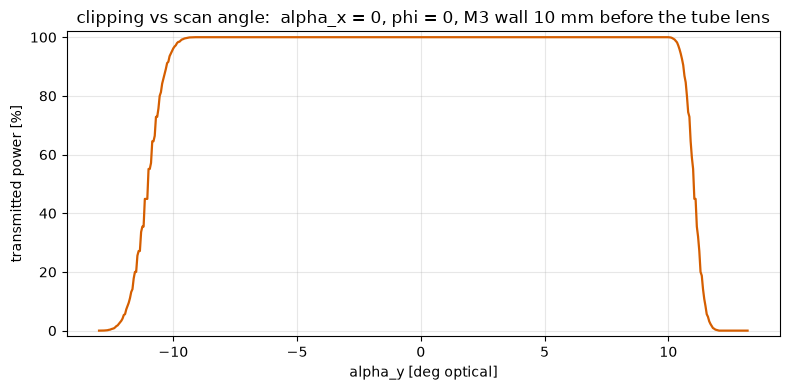

unclipped over alpha_y = -9.2 .. +10.0 deg
at the scan limits: 0.0% at -13 deg, 0.0% at +13.2 deg


In [50]:
# alpha_y sweep at the nominal housing position, every 0.5 deg. 469 rays per
# point (n = 12 hexapolar rings) out to 1.5w, weighted by power.
AY = np.arange(-SCAN_MAX, SCAN_MAX + 0.25, 0.05)
T_AY = np.array([100 * transmission(0.0, 0.0, ay) for ay in AY])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(AY, T_AY, "-", color="#D55E00", lw=1.6)
ax.set_xlabel("alpha_y [deg optical]")
ax.set_ylabel("transmitted power [%]")
ax.set_title(f"clipping vs scan angle:  alpha_x = 0, phi = 0, "
             f"M3 wall {GAP_TUBE:g} mm before the tube lens")
ax.set_ylim(-2, 102)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

_clear = AY[T_AY > 99.999]
print(f"unclipped over alpha_y = {_clear.min():+.1f} .. {_clear.max():+.1f} deg"
      if len(_clear) else "no scan angle passes unclipped")
print(f"at the scan limits: {T_AY[0]:.1f}% at {AY[0]:+g} deg, "
      f"{T_AY[-1]:.1f}% at {AY[-1]:+g} deg")


### 2.3 Transmission vs K-mirror position

The same measurement against the distance from the housing exit wall (the M3
side) to the tube lens, 10 to 200 mm. The tube lens does not move: a bigger gap
means the housing sits *further upstream*, closer to the scan lens, where the
beam has diverged less - so transmission **improves** as the gap opens. Pushing
the K-mirror up against the tube lens, which is where it sits by default, is the
worst case for clipping.

On axis nothing clips at any position and past ~12$^\circ$ nothing gets through at
any position, so the gap only shows its effect over the narrow band between; four
scan angles are drawn for that reason.

alpha_y    0 deg:   100.0% at 10 mm,  100.0% at 200 mm
alpha_y 10.5 deg:    94.4% at 10 mm,  100.0% at 200 mm
alpha_y   11 deg:    55.1% at 10 mm,   81.3% at 200 mm
alpha_y 11.5 deg:     8.4% at 10 mm,    0.0% at 200 mm


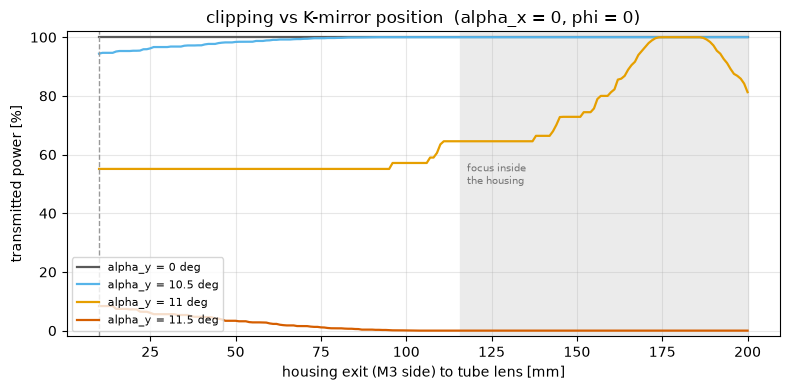

In [53]:
# transmission vs the M3-side gap to the tube lens, at alpha_x = 0, phi = 0.
# Four scan angles: on axis nothing clips at any position, and past ~12 deg
# nothing gets through at any position, so the gap only shows its effect over
# the narrow band in between.
GAPS = np.arange(10.0, 200.1, 1.0)

fig, ax = plt.subplots(figsize=(8, 4))
# beyond this gap the intermediate focus (path f_scan) falls inside the housing,
# where a geometric bundle is no longer the Gaussian envelope
_g_focus = PATH_TO_TUBE - PATH_BOX - F_SCAN
ax.axvspan(_g_focus, GAPS.max(), color="0.92", zorder=0)
ax.text(_g_focus + 2, 50, "focus inside\nthe housing", fontsize=7.5, color="0.45")
for ay, col in ((0, "0.35"), (10.5, "#56B4E9"), (11, "#E69F00"),
                (11.5, "#D55E00")):
    T = [100 * transmission(0.0, 0.0, ay, box_front=bf_of_gap(g))
         for g in GAPS]
    ax.plot(GAPS, T, "-", lw=1.6, color=col, label=f"alpha_y = {ay:g} deg")
    print(f"alpha_y {ay:4g} deg:  {T[0]:6.1f}% at 10 mm, {T[-1]:6.1f}% at 200 mm")
ax.axvline(GAP_TUBE, color="0.6", ls="--", lw=1.0)
ax.set_xlabel("housing exit (M3 side) to tube lens [mm]")
ax.set_ylabel("transmitted power [%]")
ax.set_title("clipping vs K-mirror position  (alpha_x = 0, phi = 0)")
ax.set_ylim(-2, 102)
ax.legend(fontsize=8, loc="lower left")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()
